In [ ]:
#attach google drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#install data visulization library
!pip install matplotlib-venn

**Housing Price Prediction Model**

In [ ]:
"""
Housing Price Prediction Model for Edinburgh Airbnb Listings
Author: Data Science Project
Date: 2024

This script implements three regression models:
1. Support Vector Regression (SVR)
2. Random Forest Regressor
3. XGBoost Regressor
"""

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("=" * 60)
print("HOUSING PRICE PREDICTION MODEL - EDINBURGH AIRBNB")
print("=" * 60)

HOUSING PRICE PREDICTION MODEL - EDINBURGH AIRBNB


**Data Loading and Initial Inspection**

In [ ]:
# Load the dataset
print("\n" + "=" * 60)
print("1. DATA LOADING AND INITIAL INSPECTION")
print("=" * 60)

df = pd.read_csv('/content/drive/MyDrive/Housing_Price_Prediction_Dataset/Edinburgh_Housing_Price_Prediction_Dataset.csv')

# Display basic information
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nStatistical Summary:")
print(df.describe())

# Check for missing values
print(f"\nMissing Values:")
print(df.isnull().sum())


1. DATA LOADING AND INITIAL INSPECTION

Dataset Shape: (4951, 79)

First 5 rows:
      id                         listing_url       scrape_id last_scraped  \
0  15420  https://www.airbnb.com/rooms/15420  20250921034137   2025-09-21   
1  24288  https://www.airbnb.com/rooms/24288  20250921034137   2025-09-21   
2  38628  https://www.airbnb.com/rooms/38628  20250921034137   2025-09-21   
3  44552  https://www.airbnb.com/rooms/44552  20250921034137   2025-09-21   
4  54188  https://www.airbnb.com/rooms/54188  20250921034137   2025-09-21   

        source                                               name  \
0  city scrape                  Georgian Boutique Apt City Centre   
1  city scrape  Cool central Loft, sleeps 4, 2 double bed+en-s...   
2  city scrape                              Edinburgh Holiday Let   
3  city scrape                  Double room - spacious Leith flat   
4  city scrape                            The Four Sisters Boatel   

                                        

**Exploratory Data Analysis (EDA)**


2. EXPLORATORY DATA ANALYSIS


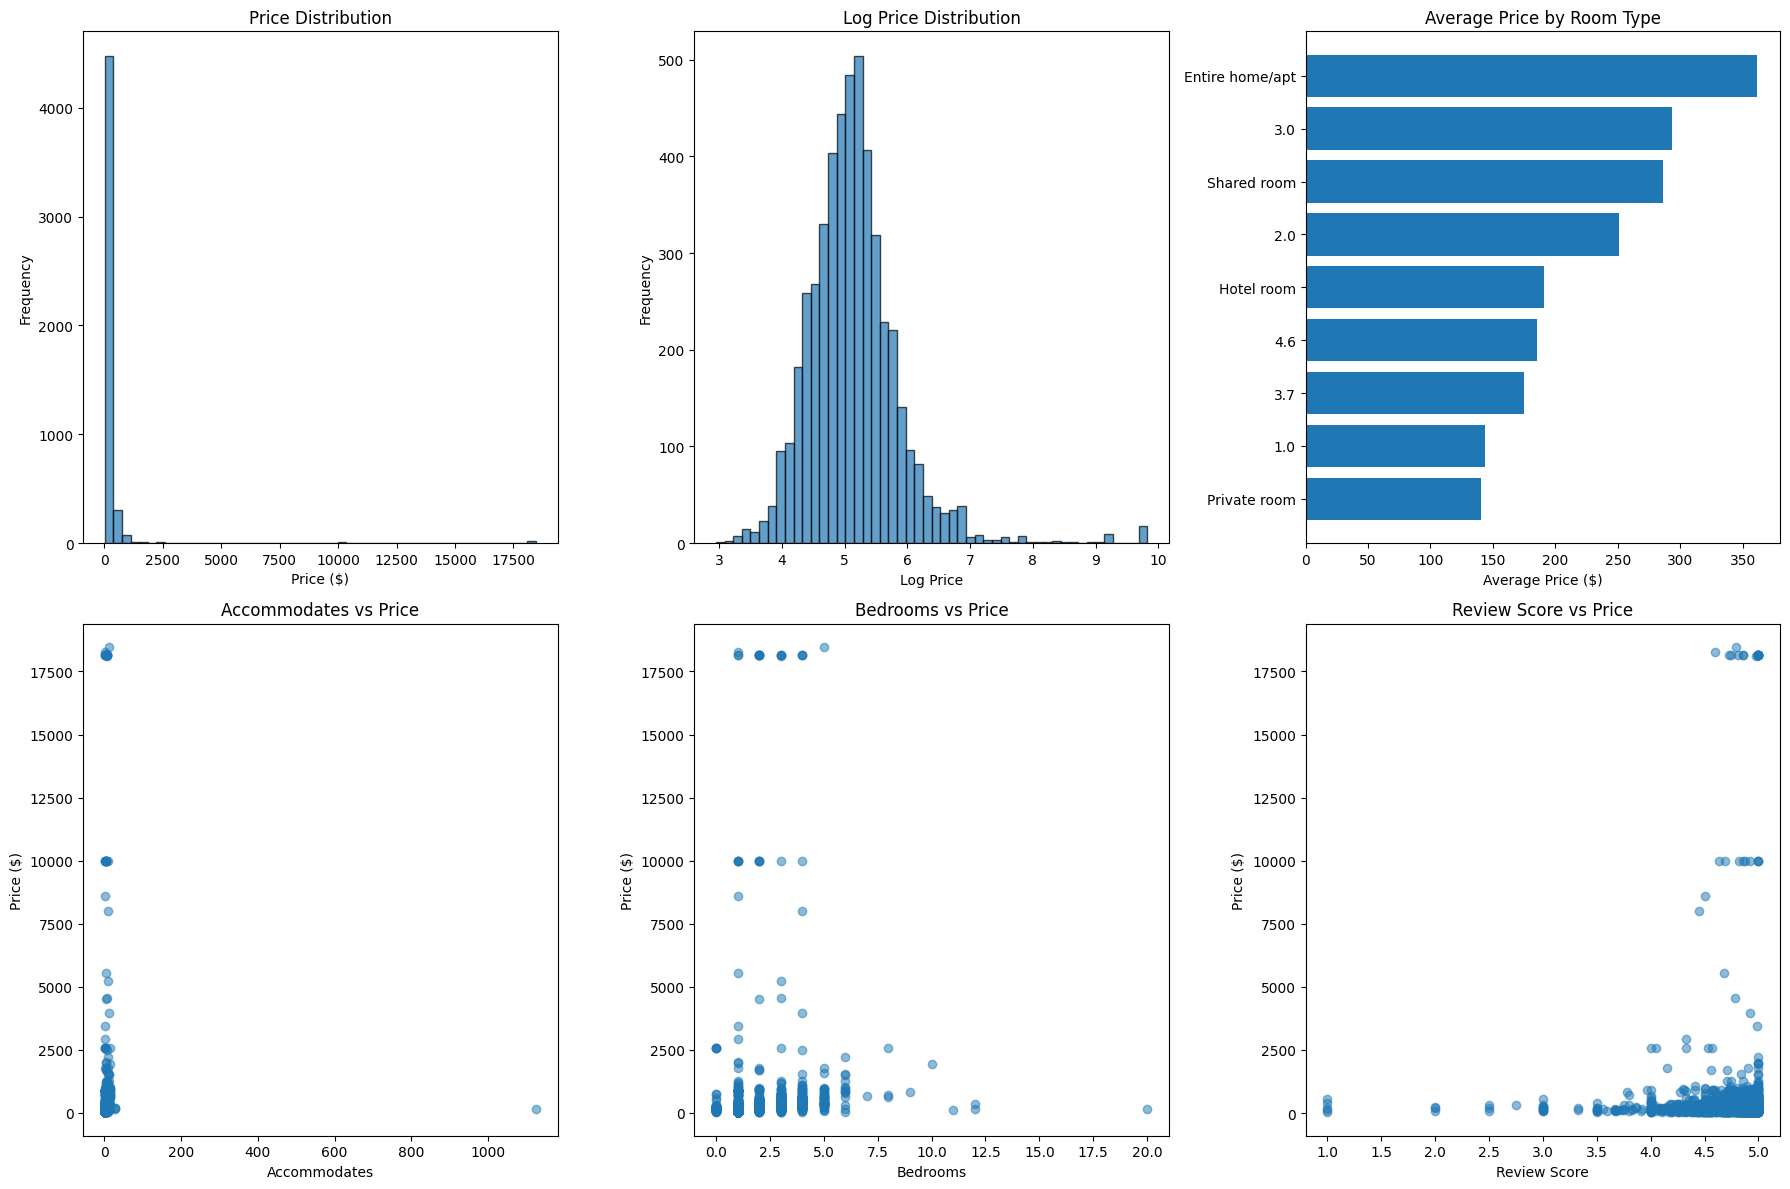

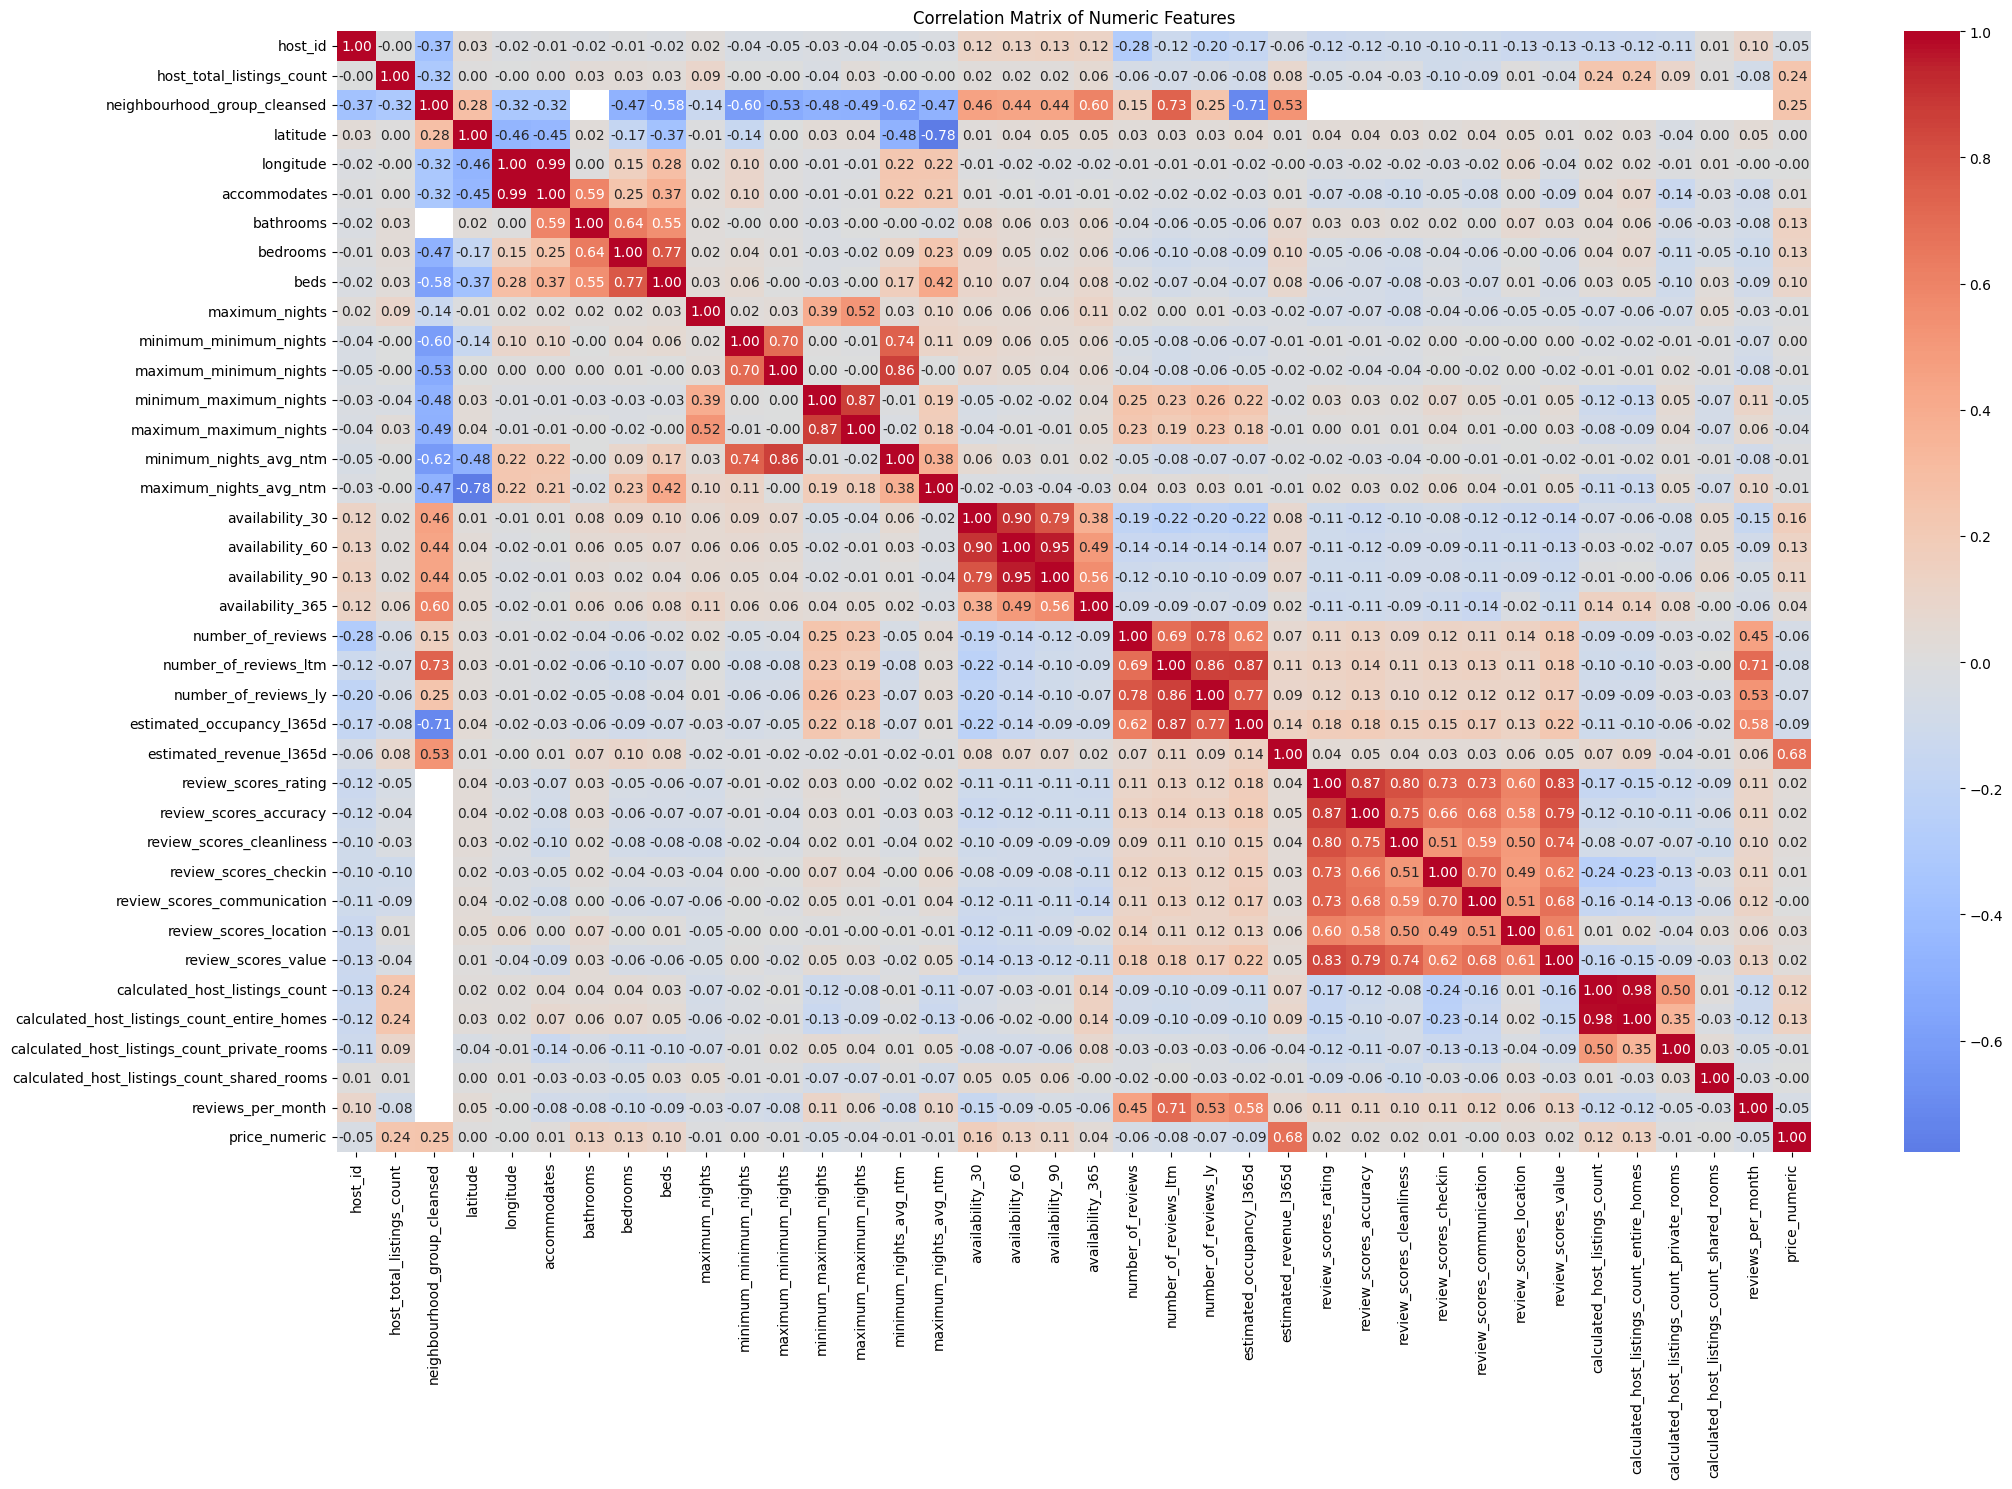

In [ ]:
print("\n" + "=" * 60)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Price distribution analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Convert price to numeric (remove $ and commas)
df['price_numeric'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Price distribution
axes[0, 0].hist(df['price_numeric'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# Log price distribution
axes[0, 1].hist(np.log1p(df['price_numeric']), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log Price Distribution')
axes[0, 1].set_xlabel('Log Price')
axes[0, 1].set_ylabel('Frequency')

# Price by room type
room_type_price = df.groupby('room_type')['price_numeric'].mean().sort_values()
axes[0, 2].barh(room_type_price.index, room_type_price.values)
axes[0, 2].set_title('Average Price by Room Type')
axes[0, 2].set_xlabel('Average Price ($)')

# Accommodates vs Price
axes[1, 0].scatter(df['accommodates'], df['price_numeric'], alpha=0.5)
axes[1, 0].set_title('Accommodates vs Price')
axes[1, 0].set_xlabel('Accommodates')
axes[1, 0].set_ylabel('Price ($)')

# Bedrooms vs Price
axes[1, 1].scatter(df['bedrooms'], df['price_numeric'], alpha=0.5)
axes[1, 1].set_title('Bedrooms vs Price')
axes[1, 1].set_xlabel('Bedrooms')
axes[1, 1].set_ylabel('Price ($)')

# Review scores vs Price
if 'review_scores_rating' in df.columns:
    axes[1, 2].scatter(df['review_scores_rating'], df['price_numeric'], alpha=0.5)
    axes[1, 2].set_title('Review Score vs Price')
    axes[1, 2].set_xlabel('Review Score')
    axes[1, 2].set_ylabel('Price ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300)
plt.show()

# Correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(22, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

**Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import ast

print("\n" + "=" * 60)
print("3. DATA PREPROCESSING")
print("=" * 60)

def preprocess_data(df):
    """
    Comprehensive data preprocessing function
    """
    # Create a copy to avoid modifying original
    data = df.copy()

    # 1. Handle price - target variable
    if 'price' in data.columns:
        data['price'] = data['price'].replace('[\$,]', '', regex=True).astype(float)

    # 2. Extract features from amenities - SAFELY
    if 'amenities' in data.columns:
        # Function to safely count amenities
        def count_amenities(amenity_str):
            if pd.isna(amenity_str):
                return 0
            try:
                # Try using ast.literal_eval for safer evaluation
                if isinstance(amenity_str, str):
                    # Replace curly quotes if present
                    amenity_str = amenity_str.replace('"', '"').replace('"', '"')
                    amenities_list = ast.literal_eval(amenity_str)
                    return len(amenities_list) if isinstance(amenities_list, list) else 0
            except:
                # If evaluation fails, try counting by commas as fallback
                try:
                    return len(amenity_str.split(','))
                except:
                    return 0
            return 0

        data['amenities_count'] = data['amenities'].apply(count_amenities)

    # 3. Extract features from bathrooms_text
    if 'bathrooms_text' in data.columns:
        data['has_bath'] = data['bathrooms_text'].str.contains('bath', case=False, na=False).astype(int)
        data['shared_bath'] = data['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)
        data['private_bath'] = data['bathrooms_text'].str.contains('private', case=False, na=False).astype(int)

        # Extract numeric bathroom count
        def extract_bathroom_count(text):
            if pd.isna(text):
                return np.nan
            # Extract numbers from text (e.g., "2 baths" -> 2)
            import re
            numbers = re.findall(r'\d+\.?\d*', str(text))
            return float(numbers[0]) if numbers else np.nan

        data['bathrooms'] = data['bathrooms_text'].apply(extract_bathroom_count)

    # 4. Process host-related features
    if 'host_response_rate' in data.columns:
        data['host_response_rate'] = data['host_response_rate'].astype(str).str.replace('%', '').str.replace('N/A', '0')
        data['host_response_rate'] = pd.to_numeric(data['host_response_rate'], errors='coerce') / 100

    if 'host_acceptance_rate' in data.columns:
        data['host_acceptance_rate'] = data['host_acceptance_rate'].astype(str).str.replace('%', '').str.replace('N/A', '0')
        data['host_acceptance_rate'] = pd.to_numeric(data['host_acceptance_rate'], errors='coerce') / 100

    # 5. Convert boolean columns
    boolean_columns = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
                       'has_availability', 'instant_bookable']

    for col in boolean_columns:
        if col in data.columns:
            data[col] = data[col].map({'t': 1, 'f': 0, 't': 1, 'f': 0, True: 1, False: 0})
            data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

    # 6. Process dates
    date_columns = ['last_scraped', 'host_since', 'first_review', 'last_review']
    current_date = pd.to_datetime('2025-09-21')

    for col in date_columns:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col], errors='coerce')
            data[f'{col}_days'] = (current_date - data[col]).dt.days

    # 7. Extract location features
    if 'latitude' in data.columns and 'longitude' in data.columns:
        # Convert to numeric if they're strings
        data['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
        data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')
        data['location_cluster'] = (data['latitude'] * 100 + data['longitude']).round(4)

    # 8. Extract property type features
    if 'property_type' in data.columns:
        # Extract main property category
        data['property_category'] = data['property_type'].str.split('·').str[0].str.strip()

    # 9. Extract room type features
    if 'room_type' in data.columns:
        # One-hot encode room type
        room_type_dummies = pd.get_dummies(data['room_type'], prefix='room_type')
        data = pd.concat([data, room_type_dummies], axis=1)

    # 10. Handle missing values
    # Fill numeric columns with median
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        data[col].fillna(data[col].median(), inplace=True)

    # Fill categorical columns with mode
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if col in data.columns and data[col].isna().any():
            mode_value = data[col].mode()[0] if len(data[col].mode()) > 0 else 'Unknown'
            data[col].fillna(mode_value, inplace=True)

    # 11. Create additional useful features
    if 'bedrooms' in data.columns and 'beds' in data.columns:
        data['bed_to_bedroom_ratio'] = data['beds'] / (data['bedrooms'] + 1)  # +1 to avoid division by zero

    if 'accommodates' in data.columns and 'bedrooms' in data.columns:
        data['people_per_bedroom'] = data['accommodates'] / (data['bedrooms'] + 1)

    if 'review_scores_rating' in data.columns:
        # Normalize review scores to 0-1 scale
        data['review_scores_norm'] = data['review_scores_rating'] / 100

    return data

# Apply preprocessing
try:
    df_processed = preprocess_data(df)
    print(f"\n✅ Processed data shape: {df_processed.shape}")
    print(f"\nProcessed data columns: {df_processed.columns.tolist()}")

    # Show summary of preprocessing
    print("\n" + "-" * 40)
    print("PREPROCESSING SUMMARY")
    print("-" * 40)
    print(f"Original shape: {df.shape}")
    print(f"Processed shape: {df_processed.shape}")
    print(f"New features created: {set(df_processed.columns) - set(df.columns)}")

    # Check for missing values after preprocessing
    missing_values = df_processed.isnull().sum()
    if missing_values.sum() > 0:
        print(f"\nColumns with remaining missing values:")
        print(missing_values[missing_values > 0])
    else:
        print(f"\n✅ No missing values remaining!")

except Exception as e:
    print(f"\n❌ Error in preprocessing: {str(e)}")
    print("\nAttempting alternative preprocessing...")

    # Simplified preprocessing as fallback
    df_processed = df.copy()

    # Just handle basic numeric conversions
    if 'price' in df_processed.columns:
        df_processed['price'] = df_processed['price'].replace('[\$,]', '', regex=True).astype(float)

    print(f"\n⚠️ Applied simplified preprocessing")
    print(f"Processed data shape: {df_processed.shape}")


3. DATA PREPROCESSING

✅ Processed data shape: (4951, 102)

Processed data columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'h

**Feature Selection and Target Definition**

In [ ]:
print("\n" + "=" * 60)
print("4. FEATURE SELECTION AND TARGET DEFINITION")
print("=" * 60)

# Define target variable
target = 'price_numeric' if 'price_numeric' in df_processed.columns else 'price'

# Select features for modeling
feature_columns = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights', 'number_of_reviews',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'amenities_count', 'has_bath', 'shared_bath',
    'private_bath', 'host_response_rate', 'host_acceptance_rate',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'instant_bookable', 'host_listings_count', 'host_total_listings_count'
]

# Add engineered date features if they exist
date_features = [col for col in df_processed.columns if '_days' in col]
feature_columns.extend(date_features)

# Filter to only include columns that exist in the dataframe
available_features = [col for col in feature_columns if col in df_processed.columns]
print(f"\nSelected features ({len(available_features)}):")
print(available_features)

# Prepare feature matrix X and target vector y
X = df_processed[available_features].copy()
y = df_processed[target].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget statistics:")
print(f"Mean price: ${y.mean():.2f}")
print(f"Median price: ${y.median():.2f}")
print(f"Min price: ${y.min():.2f}")
print(f"Max price: ${y.max():.2f}")


4. FEATURE SELECTION AND TARGET DEFINITION

Selected features (30):
['accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'amenities_count', 'has_bath', 'shared_bath', 'private_bath', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable', 'host_listings_count', 'host_total_listings_count', 'last_scraped_days', 'host_since_days', 'first_review_days', 'last_review_days']

Feature matrix shape: (4951, 30)
Target vector shape: (4951,)

Target statistics:
Mean price: $299.79
Median price: $160.00
Min price: $18.00
Max price: $18465.00
